In [6]:
! pip install torch

  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.1 MB 1.5 MB/s eta 0:01:20
   ---------------------------------------- 0.8/122.1 MB 1.5 MB/s eta 0:01:24
   ---------------------------------------- 1.0/122.1 MB 1.4 MB/s eta 0:01:27
    --------------------------------------- 1.6/122.1 MB 1.7 MB/s eta 0:01:12
    --------------------------------------- 2.4/122.1 MB 2.0 MB/s eta 0:01:01
    --------------------------------------- 2.9/122.1 MB 2.1 MB/s eta 0:00:57
   - -------------------------------------- 3.7/122.1 MB 2.3 MB/s eta 0:00:52
   - -------------------------------------- 4.5/122.1 MB 2.5 MB/s eta 0:00:48
   - -------------------------------------- 5.2/122.1 MB 2.6 MB/s eta 0:00:45
   -- --------------------

In [7]:
! pip install transformers

In [18]:
import os
import pickle
import pandas as pd
import torch

from transformers import DistilBertTokenizerFast
from sklearn.preprocessing import LabelEncoder

In [19]:
import os
from pathlib import Path
import pandas as pd

print(os.getcwd())

csv_path = Path(r"c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\data\processed\security_train_processed.csv")
train = pd.read_csv(csv_path)

c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks


In [20]:
try:
    BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    # In notebooks, __file__ is unavailable; use the project root above /notebooks.
    BASE_DIR = os.path.dirname(os.getcwd())

PROCESSED = os.path.join(BASE_DIR, "data", "processed")
OUTPUT = os.path.join(BASE_DIR, "outputs", "tokenized")

os.makedirs(OUTPUT, exist_ok=True)

In [21]:
train = pd.read_csv(
    os.path.join(PROCESSED, "security_train_processed.csv")
)

validation = pd.read_csv(
    os.path.join(PROCESSED, "security_validation_processed.csv")
)

test = pd.read_csv(
    os.path.join(PROCESSED, "security_test_processed.csv")
)

print(train.shape)
print(validation.shape)
print(test.shape)

(10059, 9)
(2306, 7)
(2306, 7)


In [22]:
train["attack_type"].value_counts()

attack_type
safe          5627
malicious     2874
phi            718
suspicious     661
jailbreak      179
Name: count, dtype: int64

In [23]:
label_encoder = LabelEncoder()

train["label"] = label_encoder.fit_transform(
    train["attack_type"]
)

validation["label"] = label_encoder.transform(
    validation["attack_type"]
)

test["label"] = label_encoder.transform(
    test["attack_type"]
)

In [24]:
mapping = pd.DataFrame({

    "Class":label_encoder.classes_,

    "Encoded Label":range(len(label_encoder.classes_))

})

mapping

,Class,Encoded Label
0,jailbreak,0
1,malicious,1
2,phi,2
3,safe,3
4,suspicious,4


In [25]:
mapping.to_csv(

    os.path.join(
        OUTPUT,
        "label_mapping.csv"
    ),

    index=False

)

with open(

    os.path.join(
        OUTPUT,
        "label_encoder.pkl"
    ),

    "wb"

) as f:

    pickle.dump(label_encoder,f)

In [26]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

In [27]:
lengths = train["prompt"].fillna("").apply(
    lambda x: len(tokenizer.tokenize(x))
)

lengths.describe()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (673 > 512). Running this sequence through the model will result in indexing errors


count    10059.000000
mean       140.228552
std        112.451406
min          1.000000
25%         47.000000
50%        128.000000
75%        201.000000
max        792.000000
Name: prompt, dtype: float64

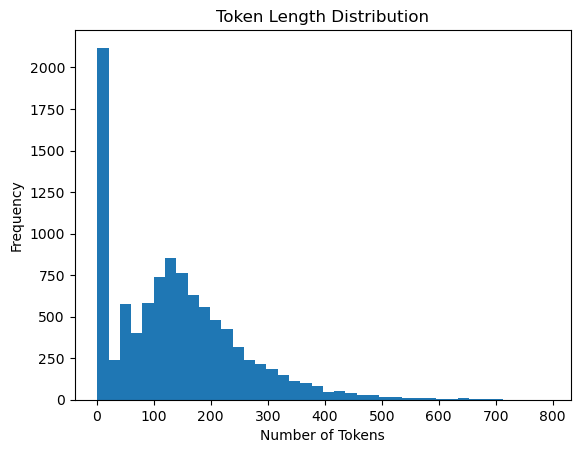

In [28]:
import matplotlib.pyplot as plt

plt.hist(lengths,bins=40)

plt.title("Token Length Distribution")

plt.xlabel("Number of Tokens")

plt.ylabel("Frequency")

plt.show()

In [29]:
MAX_LENGTH = 128

train_encoding = tokenizer(

    train["prompt"].tolist(),

    truncation=True,

    padding=True,

    max_length=MAX_LENGTH,

    return_tensors="pt"

)

validation_encoding = tokenizer(

    validation["prompt"].tolist(),

    truncation=True,

    padding=True,

    max_length=MAX_LENGTH,

    return_tensors="pt"

)

test_encoding = tokenizer(

    test["prompt"].tolist(),

    truncation=True,

    padding=True,

    max_length=MAX_LENGTH,

    return_tensors="pt"

)

In [30]:
train_encoding["labels"] = torch.tensor(
    train["label"].values
)

validation_encoding["labels"] = torch.tensor(
    validation["label"].values
)

test_encoding["labels"] = torch.tensor(
    test["label"].values
)

In [31]:
print(train_encoding.keys())

print()

print(train_encoding["input_ids"].shape)

print(train_encoding["attention_mask"].shape)

print(train_encoding["labels"].shape)

KeysView({'input_ids': tensor([[  101,  1037,  3429,  ...,     0,     0,     0],
        [  101,  2966,  3189,  ...,     0,     0,     0],
        [  101,  5776,  7710,  ...,     0,     0,     0],
        ...,
        [  101,  1037,  2570,  ..., 18847,  2669,   102],
        [  101,  1037,  1019,  ...,     0,     0,     0],
        [  101,  1037,  2603,  ...,     0,     0,     0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([4, 2, 2,  ..., 3, 3, 3], dtype=torch.int32)})

torch.Size([10059, 128])
torch.Size([10059, 128])
torch.Size([10059])


In [32]:
torch.save(

    train_encoding,

    os.path.join(
        OUTPUT,
        "train_encodings.pt"
    )

)

torch.save(

    validation_encoding,

    os.path.join(
        OUTPUT,
        "validation_encodings.pt"
    )

)

torch.save(

    test_encoding,

    os.path.join(
        OUTPUT,
        "test_encodings.pt"
    )

)

In [33]:
print(os.listdir(OUTPUT))

['label_encoder.pkl', 'label_mapping.csv', 'test_encodings.pt', 'tokenization_summary.txt', 'train_encodings.pt', 'validation_encodings.pt']


In [34]:
summary = f"""
========================================
TOKENIZATION SUMMARY
========================================

Tokenizer : DistilBERT Base Uncased

Training Samples : {len(train)}

Validation Samples : {len(validation)}

Testing Samples : {len(test)}

Maximum Sequence Length : {MAX_LENGTH}

Classes

{mapping}

========================================
"""

print(summary)

with open(

    os.path.join(
        OUTPUT,
        "tokenization_summary.txt"
    ),

    "w"

) as f:

    f.write(summary)


TOKENIZATION SUMMARY

Tokenizer : DistilBERT Base Uncased

Training Samples : 10059

Validation Samples : 2306

Testing Samples : 2306

Maximum Sequence Length : 128

Classes

        Class  Encoded Label
0   jailbreak              0
1   malicious              1
2         phi              2
3        safe              3
4  suspicious              4


